Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 408kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.4MB/s]


Training samples: 60000
Test samples: 10000
Training model from scratch...
Epoch 1/5 complete | Loss: 0.2598
Epoch 2/5 complete | Loss: 0.1122
Epoch 3/5 complete | Loss: 0.0774
Epoch 4/5 complete | Loss: 0.0592
Epoch 5/5 complete | Loss: 0.0458
Model saved as 'mnist_model.pth'
Test Accuracy: 97.90%


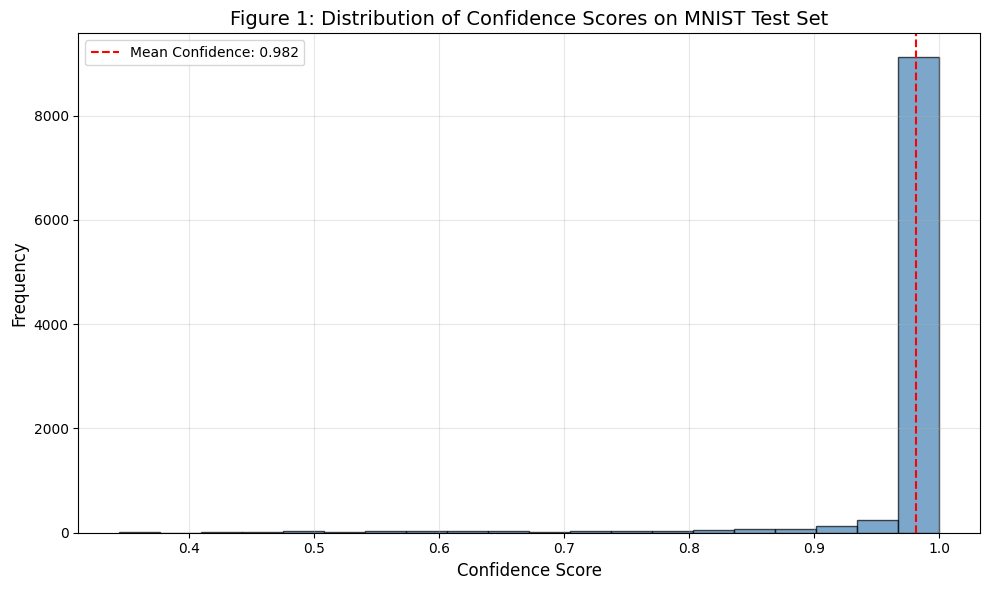

Figure 1 saved as 'figure1_confidence_distribution.png'


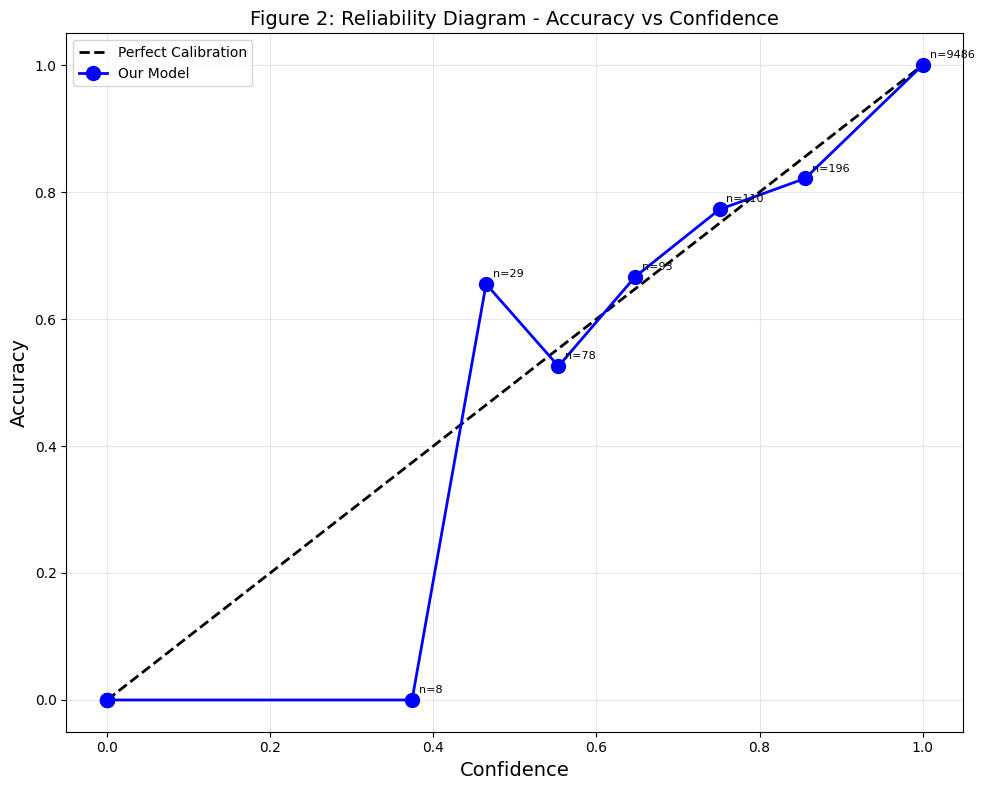

Figure 2 saved as 'figure2_reliability_diagram.png'

Calibration Metrics:
  ECE (Expected Calibration Error): 0.47%
  MCE (Maximum Calibration Error): 37.39%
  Accuracy: 97.90%
  Mean Confidence: 98.17%

Found 64 confidently wrong examples (confidence > 90%)
Percentage of all wrong predictions: 30.5%


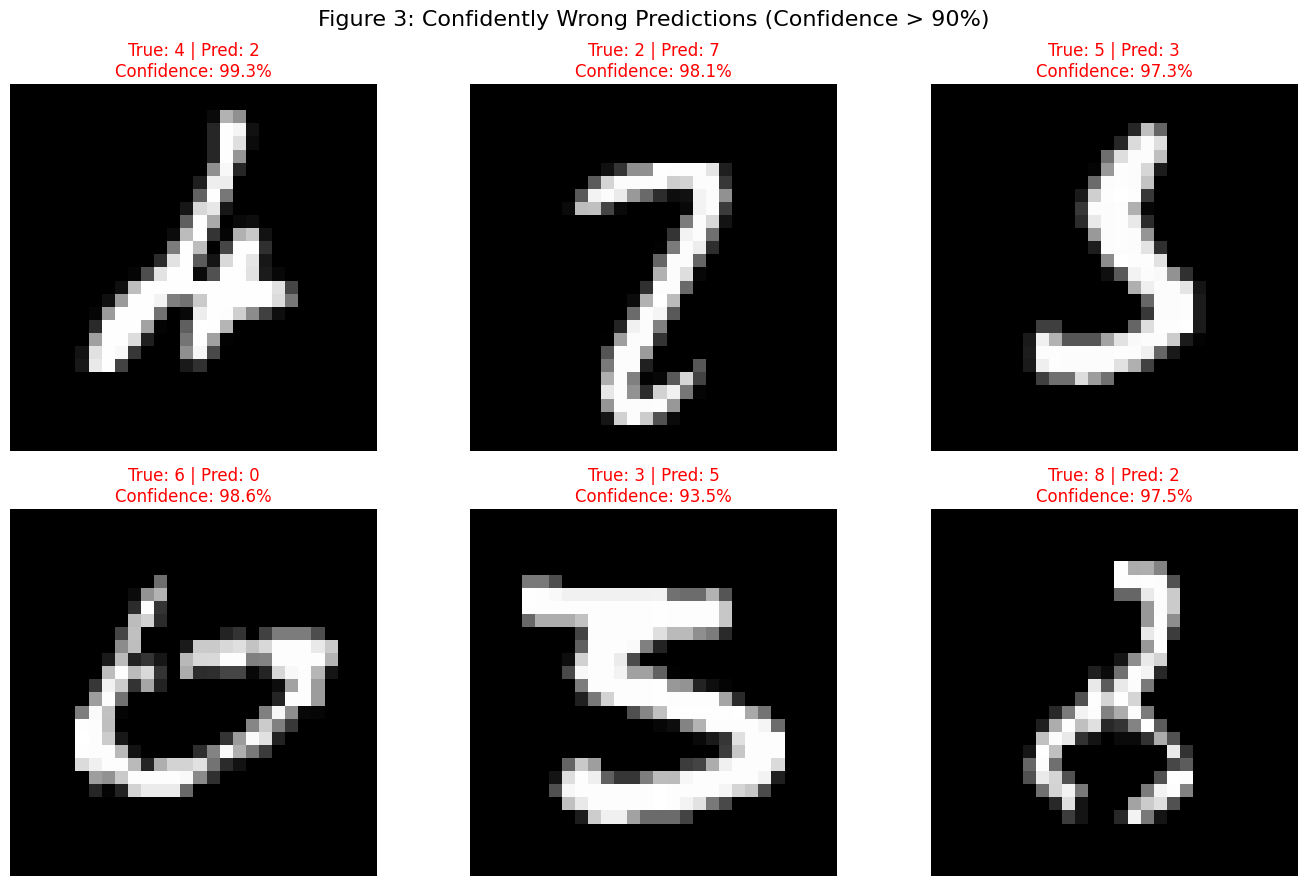

Figure 3 saved as 'figure3_confidently_wrong.png'

Detailed Analysis: First Confidently Wrong Example
True Label:4
Predicted Label:2
Confidence:99.3%

Probability distribution across all digits:
----------------------------------------
  0:   0.0% 
  1:   0.0% 
  2:  99.3% █████████████████████████████████████████████████
  3:   0.0% 
  4:   0.0% 
  5:   0.0% 
  6:   0.7% 
  7:   0.0% 
  8:   0.0% 
  9:   0.0% 


Table 1: Summary Statistics
Total test samples:10000
Correct predictions:9790 (97.9%)
Incorrect predictions:210 (2.1%)
Incorrect with >90% confidence:64
Percentage of wrong predictions >90% conf:30.5%
Expected Calibration Error (ECE):0.47%
Maximum Calibration Error (MCE):37.39%

Table 1 saved as 'table1_summary.csv'

All figures generated successfully!

Files created:
  - figure1_confidence_distribution.png
  - figure2_reliability_diagram.png
  - figure3_confidently_wrong.png
  - table1_summary.csv
  - mnist_model.pth


In [ ]:
# Step 1: Importing all Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Step 2: Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Loading MNIST dataset...")
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Step 3: Define the model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleNN()

# Step 4: Train the model
print("Training model from scratch...")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(5):
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 complete | Loss: {total_loss/len(train_loader):.4f}")

# Save the trained model
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved as 'mnist_model.pth'")

# Step 5: Evaluate on test set
model.eval()
all_targets = []
all_predictions = []
all_confidences = []
all_probabilities = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        all_targets.extend(target.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_confidences.extend(confidence.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)
all_confidences = np.array(all_confidences)
all_probabilities = np.array(all_probabilities)

correct = (all_predictions == all_targets)
accuracy = np.mean(correct)
print(f"Test Accuracy: {accuracy*100:.2f}%")


# Figure 1: Confidence Distribution Histogram
plt.figure(figsize=(10, 6))
plt.hist(all_confidences, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Figure 1: Distribution of Confidence Scores on MNIST Test Set', fontsize=14)
plt.axvline(np.mean(all_confidences), color='red', linestyle='--', label=f'Mean Confidence: {np.mean(all_confidences):.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved as 'figure1_confidence_distribution.png'")


# Figure 2: Reliability Diagram (Calibration Curve)
def compute_calibration_curve(confidences, correct, num_bins=10):
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    accuracies = []
    confs = []
    bin_counts = []

    for i in range(num_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        bin_count = np.sum(in_bin)
        bin_counts.append(bin_count)
        if bin_count > 0:
            accuracy = np.mean(correct[in_bin])
            conf = np.mean(confidences[in_bin])
        else:
            accuracy = 0
            conf = 0
        accuracies.append(accuracy)
        confs.append(conf)

    # Handle the last bin (confidences == 1.0)
    if np.any(confidences == 1.0):
        bin_counts[-1] += np.sum(confidences == 1.0)
        accuracies[-1] = np.mean(correct[confidences == 1.0]) if np.sum(confidences == 1.0) > 0 else 0
        confs[-1] = 1.0

    return np.array(confs), np.array(accuracies), np.array(bin_counts)

conf_bins, acc_bins, bin_counts = compute_calibration_curve(all_confidences, correct, num_bins=10)

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
plt.plot(conf_bins, acc_bins, 'bo-', label='Our Model', linewidth=2, markersize=10)

# Add bin size information as text
for i, (conf, acc, count) in enumerate(zip(conf_bins, acc_bins, bin_counts)):
    if count > 0:
        plt.annotate(f'n={count}', (conf, acc),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel('Confidence', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Figure 2: Reliability Diagram - Accuracy vs Confidence', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('figure2_reliability_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 2 saved as 'figure2_reliability_diagram.png'")


# Calculate ECE
def calculate_ece(confidences, correct, num_bins=10):
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    ece = 0.0
    n = len(confidences)

    for i in range(num_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        bin_count = np.sum(in_bin)
        if bin_count > 0:
            accuracy = np.mean(correct[in_bin])
            conf = np.mean(confidences[in_bin])
            ece += (bin_count / n) * np.abs(accuracy - conf)

    if np.any(confidences == 1.0):
        bin_count = np.sum(confidences == 1.0)
        if bin_count > 0:
            accuracy = np.mean(correct[confidences == 1.0])
            ece += (bin_count / n) * np.abs(accuracy - 1.0)

    return ece

def calculate_mce(confidences, correct, num_bins=10):
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    mce = 0.0

    for i in range(num_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        bin_count = np.sum(in_bin)
        if bin_count > 0:
            accuracy = np.mean(correct[in_bin])
            conf = np.mean(confidences[in_bin])
            mce = max(mce, np.abs(accuracy - conf))

    if np.any(confidences == 1.0):
        bin_count = np.sum(confidences == 1.0)
        if bin_count > 0:
            accuracy = np.mean(correct[confidences == 1.0])
            mce = max(mce, np.abs(accuracy - 1.0))

    return mce

ece = calculate_ece(all_confidences, correct, num_bins=10)
mce = calculate_mce(all_confidences, correct, num_bins=10)

print(f"\nCalibration Metrics:")
print(f"  ECE (Expected Calibration Error): {ece*100:.2f}%")
print(f"  MCE (Maximum Calibration Error): {mce*100:.2f}%")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Mean Confidence: {np.mean(all_confidences)*100:.2f}%")


# Figure 3: Confidently Wrong Examples
wrong_high_confidence = []
with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        for i in range(len(target)):
            if predicted[i] != target[i] and confidence[i] > 0.90:
                wrong_high_confidence.append({
                    'image': data[i],
                    'true_label': target[i].item(),
                    'predicted_label': predicted[i].item(),
                    'confidence': confidence[i].item(),
                    'probabilities': probabilities[i].cpu().numpy()
                })

print(f"\nFound {len(wrong_high_confidence)} confidently wrong examples (confidence > 90%)")
print(f"Percentage of all wrong predictions: {(len(wrong_high_confidence) / (10000 - int(accuracy*10000)))*100:.1f}%")

# Display top 6 examples
if len(wrong_high_confidence) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    for idx in range(min(6, len(wrong_high_confidence))):
        example = wrong_high_confidence[idx]
        img = example['image'].squeeze().numpy()

        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(
            f"True: {example['true_label']} | Pred: {example['predicted_label']}\n"
            f"Confidence: {example['confidence']*100:.1f}%",
            color='red',
            fontsize=12
        )
        axes[idx].axis('off')

    plt.suptitle('Figure 3: Confidently Wrong Predictions (Confidence > 90%)', fontsize=16)
    plt.tight_layout()
    plt.savefig('figure3_confidently_wrong.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 3 saved as 'figure3_confidently_wrong.png'")
else:
    print("No confidently wrong examples found with threshold > 90%")


# Display detailed probabilities for one example
if len(wrong_high_confidence) > 0:
    print("\n" + "="*60)
    print("Detailed Analysis: First Confidently Wrong Example")
    print("="*60)

    first = wrong_high_confidence[0]
    probs = first['probabilities']

    print(f"True Label:{first['true_label']}")
    print(f"Predicted Label:{first['predicted_label']}")
    print(f"Confidence:{first['confidence']*100:.1f}%\n")

    print("Probability distribution across all digits:")
    print("-"*40)
    for digit in range(10):
        bar = '█' * int(probs[digit] * 50)
        print(f"  {digit}: {probs[digit]*100:5.1f}% {bar}")

    print("\n" + "="*60)


# Table 1: Summary Statistics
total_samples = len(all_targets)
total_wrong = np.sum(~correct)
confidently_wrong = len(wrong_high_confidence)

print("\n" + "="*60)
print("Table 1: Summary Statistics")
print("="*60)
print(f"Total test samples:{total_samples}")
print(f"Correct predictions:{np.sum(correct)} ({accuracy*100:.1f}%)")
print(f"Incorrect predictions:{total_wrong} ({(1-accuracy)*100:.1f}%)")
print(f"Incorrect with >90% confidence:{confidently_wrong}")
print(f"Percentage of wrong predictions >90% conf:{(confidently_wrong/total_wrong)*100:.1f}%")
print(f"Expected Calibration Error (ECE):{ece*100:.2f}%")
print(f"Maximum Calibration Error (MCE):{mce*100:.2f}%")
print("="*60)


# Save table to CSV for easy reference
import csv

with open('table1_summary.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Metric', 'Value'])
    writer.writerow(['Total test samples', total_samples])
    writer.writerow(['Correct predictions', f"{np.sum(correct)} ({accuracy*100:.1f}%)"])
    writer.writerow(['Incorrect predictions', f"{total_wrong} ({(1-accuracy)*100:.1f}%)"])
    writer.writerow(['Incorrect with >90% confidence', confidently_wrong])
    writer.writerow(['% of wrong predictions >90% conf', f"{(confidently_wrong/total_wrong)*100:.1f}%"])
    writer.writerow(['ECE', f"{ece*100:.2f}%"])
    writer.writerow(['MCE', f"{mce*100:.2f}%"])

print("\nTable 1 saved as 'table1_summary.csv'")

print("\n" + "="*60)
print("All figures generated successfully!")
print("="*60)
print("\nFiles created:")
print("  - figure1_confidence_distribution.png")
print("  - figure2_reliability_diagram.png")
print("  - figure3_confidently_wrong.png")
print("  - table1_summary.csv")
print("  - mnist_model.pth")